In [1]:
import anndata
import networkx as nx
import numpy as np
import scgenome.plotting as pl

from cellmates.utils.math_utils import compute_cn_changes
from cellmates.utils.tree_utils import f1_score_clades, relabel_name_to_int, newick_to_nx, convert_networkx_to_dendropy, \
    nxtree_to_newick, normalized_rf_distance

/home/vittorio.zampinetti/miniforge3/envs/cellmates/lib/python3.10/site-packages/scgenome/refgenome.py:3: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


# Analysis for MM03 dataset

## bahlis_10x MM03

In [2]:
path = "/home/vittorio.zampinetti/data/patient_MM-03.h5ad"

adata = anndata.read_h5ad(path)
adata

AnnData object with n_obs × n_vars = 2208 × 5298
    obs: 'cell_id', 'effective_depth_of_coverage', 'effective_reads_per_1Mbp', 'est_cnv_resolution_mb', 'frac_mapped_duplicates', 'is_high_dimapd', 'is_noisy', 'mean_ploidy', 'normalized_dimapd', 'normalized_mapd', 'num_duplicate_reads', 'num_lowmapq_reads', 'num_mapped_dedup_reads', 'num_unmapped_reads', 'ploidy_confidence', 'raw_dimapd', 'raw_mapd', 'total_num_reads', 'state_mean', 'state_var', 'is_normal', 'patient_id', 'dataset', 'description', 'cluster_id', 'cluster_size', 'cell_order'
    var: 'chr', 'start', 'end', 'gc_fraction', 'cyto_band_name', 'cyto_band_giemsa_stain'
    uns: 'clustering'
    layers: 'copy', 'normalized_counts', 'state'

In [3]:
#manipulate chr
chr_codes = {c: c[3:] for c in adata.var['chr'].unique()}
adata.var['chr'] = adata.var['chr'].map(chr_codes)

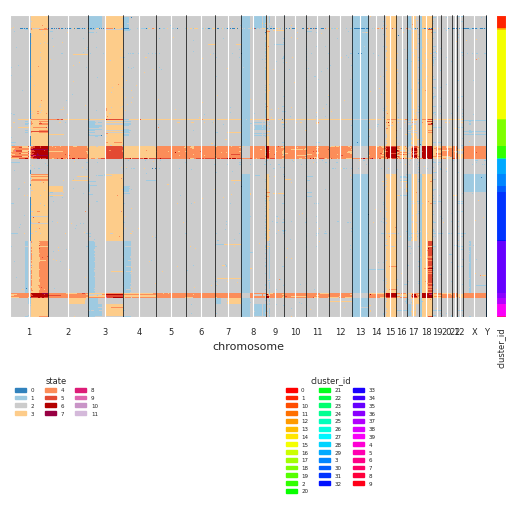

In [4]:
g = pl.plot_cell_cn_matrix_fig(adata, cell_order_fields=['cluster_id'], annotation_fields=['cluster_id'])

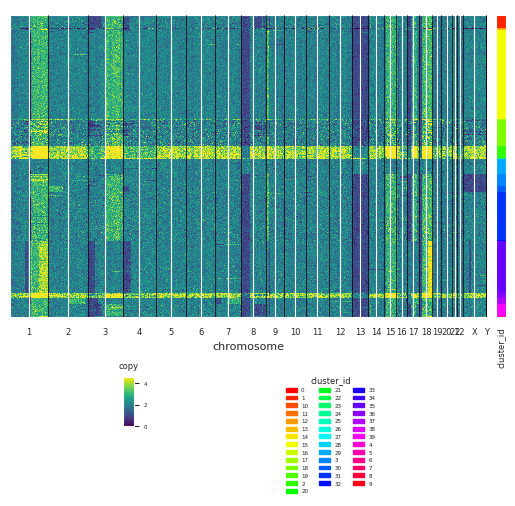

In [5]:
perc_98 = np.nanquantile(adata.layers['copy'], .98)
g = pl.plot_cell_cn_matrix_fig(adata, layer_name='copy', cell_order_fields=['cluster_id'], annotation_fields=['cluster_id'], raw=True, vmax=perc_98)

### Zoom on WGD cells

In [6]:
adata[adata.obs['mean_ploidy'] > 3]

View of AnnData object with n_obs × n_vars = 138 × 5298
    obs: 'cell_id', 'effective_depth_of_coverage', 'effective_reads_per_1Mbp', 'est_cnv_resolution_mb', 'frac_mapped_duplicates', 'is_high_dimapd', 'is_noisy', 'mean_ploidy', 'normalized_dimapd', 'normalized_mapd', 'num_duplicate_reads', 'num_lowmapq_reads', 'num_mapped_dedup_reads', 'num_unmapped_reads', 'ploidy_confidence', 'raw_dimapd', 'raw_mapd', 'total_num_reads', 'state_mean', 'state_var', 'is_normal', 'patient_id', 'dataset', 'description', 'cluster_id', 'cluster_size', 'cell_order'
    var: 'chr', 'start', 'end', 'gc_fraction', 'cyto_band_name', 'cyto_band_giemsa_stain'
    uns: 'clustering'
    layers: 'copy', 'normalized_counts', 'state'

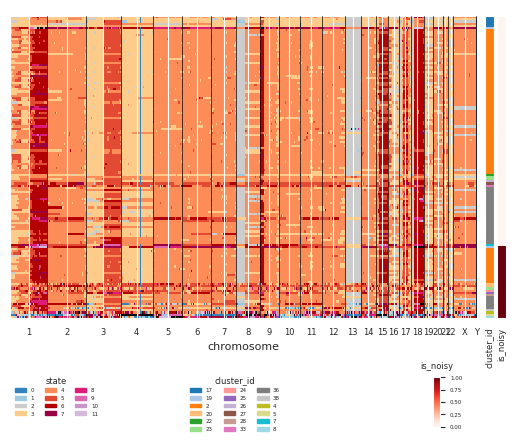

In [7]:
perc_99 = np.nanquantile(adata[(adata.obs['mean_ploidy'] > 3)].layers['copy'], .99)
# g = pl.plot_cell_cn_matrix_fig(adata[adata.obs['mean_ploidy'] > 3], layer_name='copy', cell_order_fields=['is_noisy', 'cluster_id'], annotation_fields=['cluster_id', 'is_noisy'], raw=True, vmax=perc_99)
g = pl.plot_cell_cn_matrix_fig(adata[adata.obs['mean_ploidy'] > 3], layer_name='state', cell_order_fields=['is_noisy', 'cluster_id'], annotation_fields=['cluster_id', 'is_noisy'])

In [8]:
# set adata to wgd dataset
adata = adata[(adata.obs['mean_ploidy'] > 3) & (~adata.obs['is_noisy'])].copy()

#### KMeans clustering

Keeping bins without nans: 5285 / 5298
Running KMeans with K=4
  Silhouette score: 0.4146
Running KMeans with K=5
  Silhouette score: 0.4164
Running KMeans with K=6
  Silhouette score: 0.2652
Running KMeans with K=7
  Silhouette score: 0.1990
Running KMeans with K=8
  Silhouette score: 0.1058
Running KMeans with K=9
  Silhouette score: 0.1200

Best K: 5 with silhouette score: 0.4164


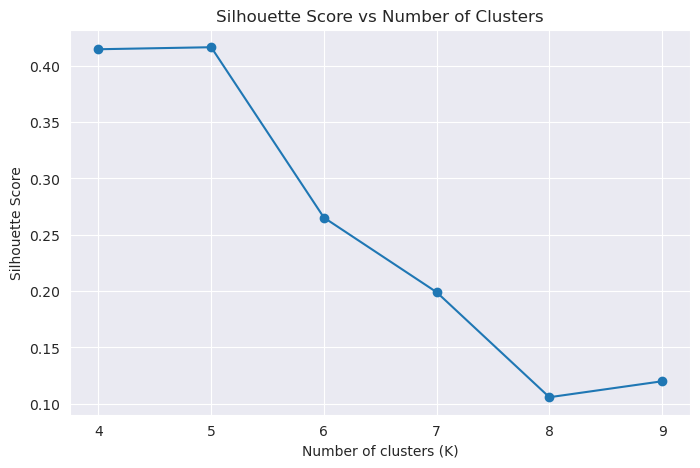

In [9]:
rerun_kmeans = True
if rerun_kmeans:
    from sklearn.cluster import KMeans
    from sklearn.metrics import silhouette_score

    kval = [4, 5, 6, 7, 8, 9]
    valid_bins = ~np.any(np.isnan(adata.layers['state']), axis=0)
    print(f"Keeping bins without nans: {np.sum(valid_bins)} / {adata.n_vars}")
    cn_mat = adata[:, valid_bins].layers['state']

    silhouette_scores = []
    best_k = None
    best_score = -1
    best_labels = None

    for k in kval:
        print(f"Running KMeans with K={k}")
        km = KMeans(n_clusters=k, random_state=42, n_init=10)
        labels = km.fit_predict(cn_mat)

        # Calculate silhouette score
        score = silhouette_score(cn_mat, labels)
        silhouette_scores.append(score)
        print(f"  Silhouette score: {score:.4f}")

        # Track best k
        if score > best_score:
            best_score = score
            best_k = k
            best_labels = labels

    print(f"\nBest K: {best_k} with silhouette score: {best_score:.4f}")

    # Optional: visualize results
    import matplotlib.pyplot as plt
    plt.figure(figsize=(8, 5))
    plt.plot(kval, silhouette_scores, marker='o')
    plt.xlabel('Number of clusters (K)')
    plt.ylabel('Silhouette Score')
    plt.title('Silhouette Score vs Number of Clusters')
    plt.grid(True)
    plt.show()

    # Store best clustering in adata
    adata.obs[f'kmeans_k{best_k}'] = best_labels
else:
    print("Best K: 9 with silhouette score: 0.4477")

#### Leiden clustering


Running Leiden with resolution=0.5
  Clusters: 3
  Silhouette: 0.0132
  Davies-Bouldin: 2.5614 (lower is better)
  Calinski-Harabasz: 7.87 (higher is better)

Running Leiden with resolution=0.7
  Clusters: 3
  Silhouette: 0.0132
  Davies-Bouldin: 2.5614 (lower is better)
  Calinski-Harabasz: 7.87 (higher is better)

Running Leiden with resolution=1.0
  Clusters: 3
  Silhouette: 0.0170
  Davies-Bouldin: 2.5687 (lower is better)
  Calinski-Harabasz: 7.92 (higher is better)

Running Leiden with resolution=1.5
  Clusters: 6
  Silhouette: -0.0918
  Davies-Bouldin: 2.4152 (lower is better)
  Calinski-Harabasz: 5.74 (higher is better)

Running Leiden with resolution=2.0
  Clusters: 10
  Silhouette: -0.1116
  Davies-Bouldin: 2.2861 (lower is better)
  Calinski-Harabasz: 4.20 (higher is better)

=== Summary ===
   resolution  n_clusters  silhouette  davies_bouldin  calinski_harabasz
0         0.5           3    0.013238        2.561387           7.868904
1         0.7           3    0.013238  

/tmp/ipykernel_1471594/4262723882.py:21: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(adata_filt, resolution=res, key_added=f'leiden_r{res}')


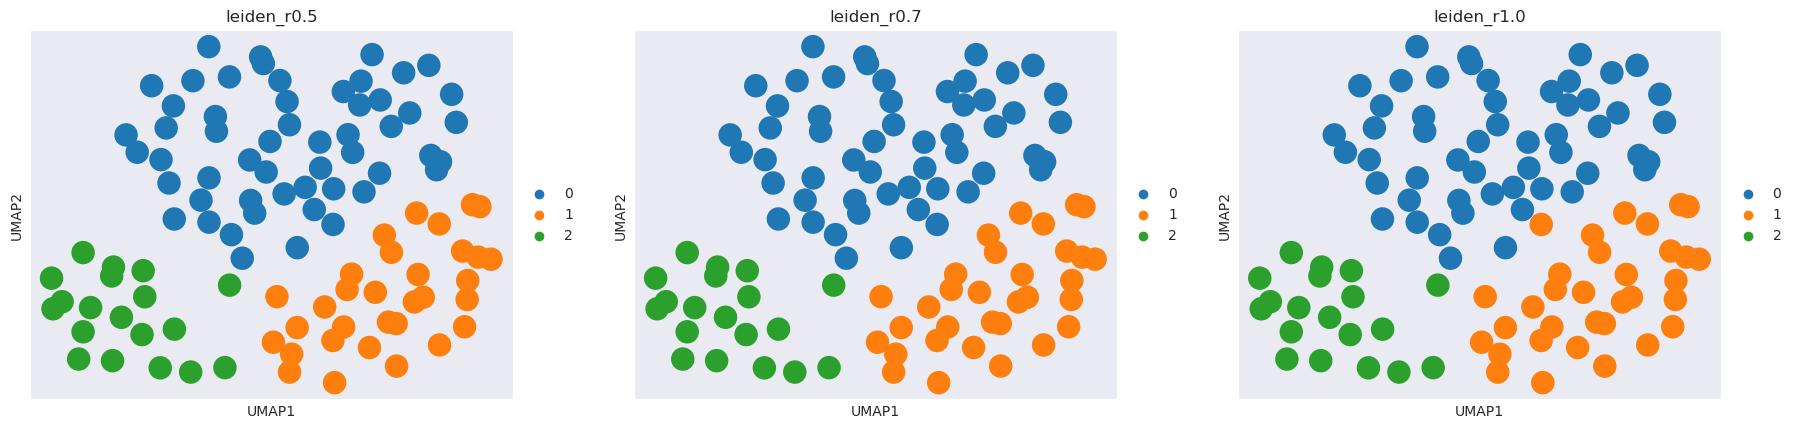

In [10]:
rerun_leiden = True
if rerun_leiden:
    import scanpy as sc
    import numpy as np

    # 1. First, compute neighbors on your CN state data (not the default adata.X)
    # Temporarily store filtered CN data in adata.X for neighbor computation
    valid_bins = ~np.any(np.isnan(adata.layers['state']), axis=0)
    adata_filt = adata[:, valid_bins].copy()
    adata_filt.X = adata_filt.layers['state']

    # 2. Compute neighbors on the CN data
    sc.pp.neighbors(adata_filt, n_neighbors=15, n_pcs=0, metric='manhattan')  # n_pcs=0 means use raw data, no PCA

    # 3. Try different resolutions and evaluate with multiple metrics
    resolutions = [0.5, 0.7, 1.0, 1.5, 2.0]
    results = []

    for res in resolutions:
        print(f"\nRunning Leiden with resolution={res}")
        sc.tl.leiden(adata_filt, resolution=res, key_added=f'leiden_r{res}')

        labels = adata_filt.obs[f'leiden_r{res}'].astype('category').cat.codes.values
        n_clusters = len(np.unique(labels))

        # Calculate multiple metrics
        from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

        sil_score = silhouette_score(adata_filt.X, labels)
        db_score = davies_bouldin_score(adata_filt.X, labels)  # Lower is better
        ch_score = calinski_harabasz_score(adata_filt.X, labels)  # Higher is better

        adata.obs[f'leiden_r{res}'] = labels

        results.append({
            'resolution': res,
            'n_clusters': n_clusters,
            'silhouette': sil_score,
            'davies_bouldin': db_score,
            'calinski_harabasz': ch_score
        })

        print(f"  Clusters: {n_clusters}")
        print(f"  Silhouette: {sil_score:.4f}")
        print(f"  Davies-Bouldin: {db_score:.4f} (lower is better)")
        print(f"  Calinski-Harabasz: {ch_score:.2f} (higher is better)")


    # 5. Summary and best resolution selection
    import pandas as pd
    results_df = pd.DataFrame(results)
    print("\n=== Summary ===")
    print(results_df)

    # Best by different metrics
    best_sil = results_df.loc[results_df['silhouette'].idxmax()]
    best_db = results_df.loc[results_df['davies_bouldin'].idxmin()]
    best_ch = results_df.loc[results_df['calinski_harabasz'].idxmax()]

    print(f"\nBest by Silhouette: resolution={best_sil['resolution']}, score={best_sil['silhouette']:.4f}")
    print(f"Best by Davies-Bouldin: resolution={best_db['resolution']}, score={best_db['davies_bouldin']:.4f}")
    print(f"Best by Calinski-Harabasz: resolution={best_ch['resolution']}, score={best_ch['calinski_harabasz']:.2f}")
    # 6. Optional: Visualize if you have UMAP/PCA
    sc.tl.umap(adata_filt)
    sc.pl.umap(adata_filt, color=[f'leiden_r{r}' for r in [0.5, 0.7, 1.0]])#%% md
else:
    print("Not run yet")

#### Conclusions
Both clustering methods find very poor clustering, therefore we can conclude that this dataset, despite the motivation, is just trash (it doesn't suit our purposes)

### Cellmates tree

In [11]:
import os
import io
from Bio import Phylo

cm_out_dir = "/home/vittorio.zampinetti/cellmates_res/real_data/MM_03_cm_out"
cell_names = open(os.path.join(cm_out_dir, "cell_names.txt")).read().splitlines()
tree_nwk = open(os.path.join(cm_out_dir, "tree.nwk")).read().strip()
nx_tree = newick_to_nx(tree_nwk)
bio_tree = Phylo.read(io.StringIO(nxtree_to_newick(nx_tree, weight='weight')), "newick")
# bio_tree = Phylo.read(io.StringIO(nxtree_to_newick(nx_tree)), "newick")
print(tree_nwk)
print(len(cell_names), adata[cell_names].n_obs)
print(cell_names, adata[cell_names].obs.index.tolist())

(TCATTACAGCGTAATA-1:0.0005274156477631791,(CGCGGTACATAGGTCT-1:0.002233543106343743,((CCTAGCTCACAACTTG-1:0.0007423458272827918,TTCTACAGTCTGCCAG-1:0.0014474517529782214)ancestor3:0.001754194723773014,(GCTGGGTCACGGAGTA-1:0.0006139316363010664,(AAGTCTGCACAAGGAC-1:0.0008240545668808146,(((TACACGAAGCAACGGT-1:5.444177960651982e-05,(AACCGCGTCAGATGTC-1:0.00016849274295589444,AGCTCTCAGGCCCTCA-1:0.0001365928466950871)ancestor12:0.00029104321693973435)ancestor10:0.0002756545006985967,(AAACGGGTCGCTAGTA-1:0.0011257397227152938,((GGCTCGATCAAAGTGA-1:0.000638247842160521,(CGACCTTTCCGCACGA-1:0.0014904037476923249,(GGGAATGAGCTAAGAT-1:0.001424563485500808,(GTCTCGTAGCAGTAGC-1:0.003764855362226396,(CAACCTCGTGATACCT-1:0.004215220872732085,(CAACCTCAGCTCTCGG-1:0.0013033466948416767,(GATCTAGAGAAACCCG-1:0.009469821736218614,((CGCCAAGCAGGTTAAA-1:0.01783423877638846,(CAGCCGACACCAAAGG-1:0.026128723945167687,(TTGGCAATCTTTCGCG-1:0.043018270098801575,(CCTCTGAGTAACTAAG-1:0.0981179973437965,TGGGCGTCATATCGTG-1:0.12241777

In [12]:
# add cellmates cn
def get_cellmates_cn_matrix(pred_file="predicted_copy_numbers.npz"):
    prediction = np.load(os.path.join(cm_out_dir, pred_file))
    cn_mat = prediction['data']
    labels = prediction['labels']  # [cell0, cell1, ..., ancestor3, ..., root]
    cn_mat.shape
    map_cells = {l: i for i, l in enumerate(labels)}
    cell_cn_mat = cn_mat[[map_cells[c] for c in cell_names]]
    return cell_cn_mat


In [13]:
adata.layers['cellmates-cn'] = get_cellmates_cn_matrix()
adata.layers['cellmates-cn-jitter'] = get_cellmates_cn_matrix("predicted_copy_numbers_cn.npz")

In [14]:
# clustering_lab = 'leiden_r0.5'
clustering_lab = 'kmeans_k5'

/home/vittorio.zampinetti/miniforge3/envs/cellmates/lib/python3.10/site-packages/scgenome/plotting/heatmap.py:394: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs['phylo_order'] = -1


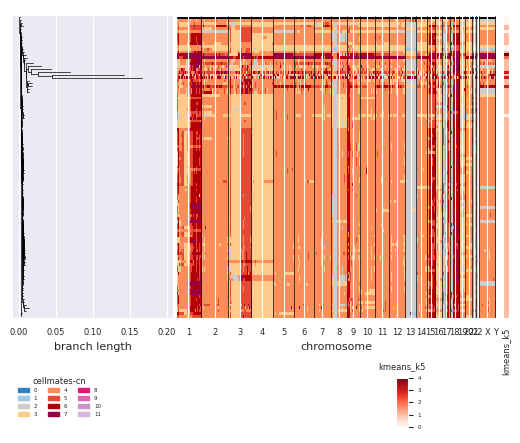

In [15]:
# g = pl.plot_cell_cn_matrix_fig(adata[cell_names], layer_name='state', tree=bio_tree, annotation_fields=[clustering_lab])
g = pl.plot_cell_cn_matrix_fig(adata[cell_names], layer_name='cellmates-cn', tree=bio_tree, annotation_fields=[clustering_lab])
# log-scale branches maybe

/home/vittorio.zampinetti/miniforge3/envs/cellmates/lib/python3.10/site-packages/scgenome/plotting/heatmap.py:394: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs['phylo_order'] = -1


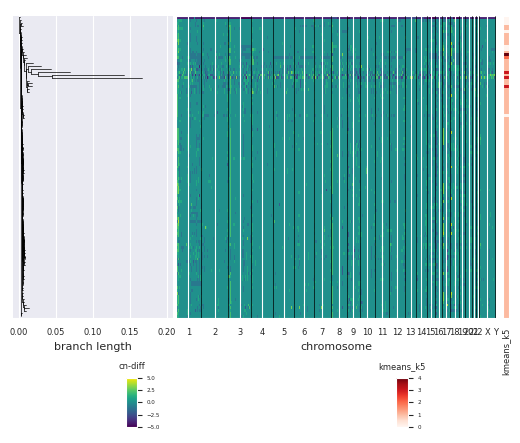

In [16]:
adata.layers['cn-diff'] = adata.layers['cellmates-cn'] - np.clip(adata.layers['state'], a_min=0, a_max=8)
# adata.layers['cn-reads-diff'] = adata.layers['cellmates-cn'] - np.clip(adata.layers['copy'], a_min=0, a_max=8)
g = pl.plot_cell_cn_matrix_fig(adata[cell_names], layer_name='cn-diff', tree=bio_tree, annotation_fields=[clustering_lab], raw=True)
# g = pl.plot_cell_cn_matrix_fig(adata[cell_names], layer_name='cn-reads-diff', tree=bio_tree, annotation_fields=[clustering_lab], raw=True)

In [17]:
cm_cn_mad = np.nanmean(np.abs(adata.layers['cellmates-cn'] - adata.layers['state']))
# cm_cn_mad = np.nanmean(np.abs(adata.layers['cellmates-cn-jitter'] - adata.layers['state']))
print(f"CN MAD against original (HMMcopy) {cm_cn_mad}")

CN MAD against original (HMMcopy) 0.1997890078870004


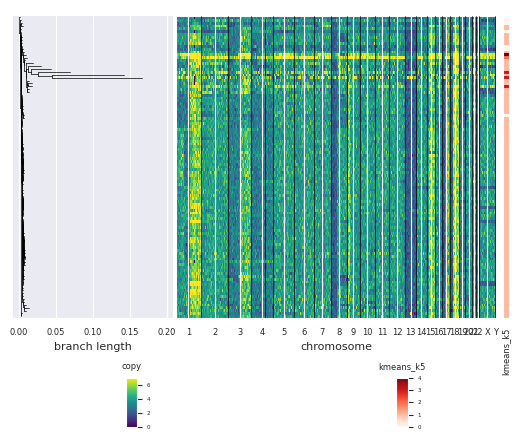

In [18]:
perc_98 = np.nanquantile(adata.layers['copy'], .98)
g = pl.plot_cell_cn_matrix_fig(adata, layer_name='copy', tree=bio_tree, annotation_fields=[clustering_lab], raw=True, vmax=perc_98)

In [19]:
nx_tree_int = relabel_name_to_int(nx_tree, cell_names)
dpy_tree = convert_networkx_to_dendropy(nx_tree_int, edge_length='weight')
f1_score = f1_score_clades(dpy_tree, adata[cell_names].obs[clustering_lab])

In [20]:
f1_score

0.42281179138321995

### MEDICC2

In [21]:
medicc_adata = anndata.read_h5ad(os.path.join(cm_out_dir, "medicc2", "MM03_medicc2_output.h5ad"))
medicc_adata_cells = medicc_adata[cell_names].copy()
medicc_adata_cells.obs[clustering_lab] = adata[medicc_adata_cells.obs_names].obs[clustering_lab]
medicc_adata_cells.layers['copy'] = adata[medicc_adata_cells.obs_names, medicc_adata_cells.var_names].layers['copy']
medicc_adata_cells

AnnData object with n_obs × n_vars = 105 × 5298
    obs: 'is_ancestor', 'branch_length', 'kmeans_k5'
    var: 'chrom', 'start', 'end'
    uns: 'medicc2_pairwise_distances', 'medicc2_summary', 'medicc2_tree_newick'
    layers: 'copy'

In [22]:
# add cn to adata
import pandas as pd
cn_df = pd.read_csv(os.path.join(cm_out_dir, "medicc2", "MM03_medicc2_input_final_final_cn_profiles.tsv"), delimiter='\t')
cn_tab = cn_df.pivot(index='sample_id', columns=['chrom', 'start', 'end'], values='total_cn')
assert np.all([c in cn_tab.index for c in cell_names])
medicc_adata_cells.layers['medicc2-cn'] = cn_tab.loc[cell_names]


In [23]:
medicc_adata_cells.var['chr'] = medicc_adata_cells.var['chrom']
#manipulate chr
chr_codes = {c: c[3:] for c in medicc_adata_cells.var['chr'].unique()}
medicc_adata_cells.var['chr'] = medicc_adata_cells.var['chr'].map(chr_codes)

In [24]:
# CONVERT MEDICC TREE TO BIO TREE
# need to re-root so to include only the tumor cells
# internal_7 was found by printing the successors of 'diploid' ancestor (that is 'None')
med_tree_nwk = medicc_adata_cells.uns['medicc2_tree_newick']
med_nx_tree = newick_to_nx(med_tree_nwk)
edges = [(u, v, med_nx_tree.edges[u,v]['weight']) for (u, v) in nx.dfs_tree(med_nx_tree, 'internal_7').edges]
med_nx_tree = nx.DiGraph()
med_nx_tree.add_weighted_edges_from(edges)
# print([(n, nx.ancestors(med_nx_tree, n)) for n in med_nx_tree.nodes if (med_nx_tree.out_degree(n) == 0 and n not in cell_names)])
# print(list(med_nx_tree.successors('None')))
med_bio_tree = Phylo.read(io.StringIO(nxtree_to_newick(med_nx_tree, weight='weight')), format="newick")
med_nx_tree = relabel_name_to_int(med_nx_tree, cell_names)
med_dpy_tree = convert_networkx_to_dendropy(med_nx_tree, edge_length='weight', taxon_namespace=dpy_tree.taxon_namespace)
med_f1_score = f1_score_clades(med_dpy_tree, medicc_adata_cells.obs[clustering_lab])

In [25]:
med_f1_score

0.6591800356506238

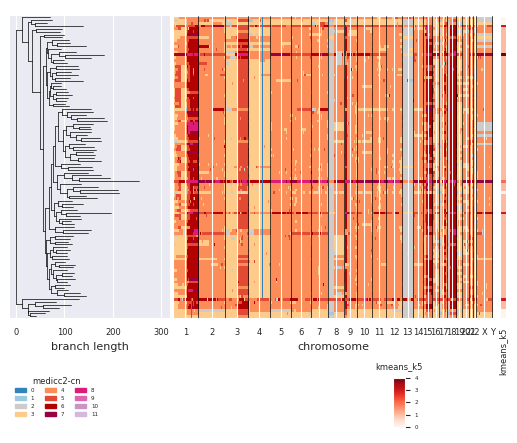

In [26]:
# g = pl.plot_cell_cn_matrix_fig(medicc_adata_cells, layer_name=None, tree=med_bio_tree, annotation_fields=[clustering_lab])
g = pl.plot_cell_cn_matrix_fig(medicc_adata_cells, layer_name='medicc2-cn', tree=med_bio_tree, annotation_fields=[clustering_lab])


### MEDICC2 tree on cellmates copy number profile

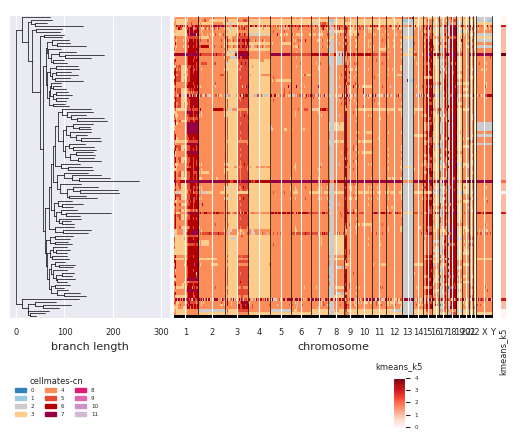

In [27]:
# plot cellmates cn onto medicc tree
medicc_adata_cells.layers['cellmates-cn'] = adata[cell_names, medicc_adata_cells.var_names].layers['cellmates-cn']
g = pl.plot_cell_cn_matrix_fig(medicc_adata_cells, layer_name='cellmates-cn', tree=med_bio_tree, annotation_fields=[clustering_lab])


In [28]:
med_cn_mad = np.nanmean(np.abs(medicc_adata_cells[cell_names, adata.var_names].layers['medicc2-cn'] - adata[cell_names].layers['state']))
print(f"MEDICC2 CN MAD against original (HMMcopy) {med_cn_mad} - cellmates CN MAD agains original: {cm_cn_mad}")
print(f"MEDICC2 CN MAD against cellmates: {np.nanmean(np.abs(medicc_adata_cells[cell_names, adata.var_names].layers['medicc2-cn'] - adata[cell_names].layers['cellmates-cn']))}")

MEDICC2 CN MAD against original (HMMcopy) 0.003940799789727997 - cellmates CN MAD agains original: 0.1997890078870004
MEDICC2 CN MAD against cellmates: 0.1999011307052077


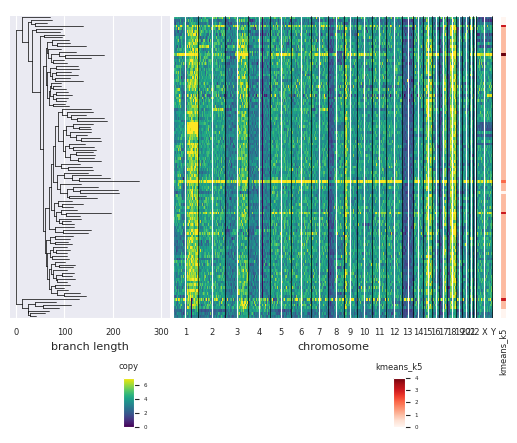

In [29]:
perc_98 = np.nanquantile(medicc_adata_cells.layers['copy'], .98)
g = pl.plot_cell_cn_matrix_fig(medicc_adata_cells, layer_name='copy', tree=med_bio_tree, annotation_fields=[clustering_lab], raw=True, vmax=perc_98)

In [31]:
# compare trees with RF
normalized_rf_distance(dpy_tree, med_dpy_tree)

0.9805825242718447

## Analyse branch lengths

In [32]:
from cellmates.utils.math_utils import compute_cn_changes
import seaborn as sns
from scipy.stats import pearsonr

def get_cells_branch_lengths(tree_nwk, cell_names):
    # traverse the tree and sum lengths over branches
    nx_tree = newick_to_nx(tree_nwk)
    root = [n for n,d in nx_tree.in_degree() if d==0][0]
    cell_lengths = []
    for c in cell_names:
        cell_lengths.append(nx.shortest_path_length(nx_tree, root, c, weight='weight'))

    return cell_lengths

def get_cells_cn_changes(cn_mat, cell_names, root_ploidy = 2):
    cell_cn_changes = []
    root_cn = np.zeros_like(cn_mat[0]) + root_ploidy
    for c in range(len(cell_names)):
        cell_cn_changes.append(compute_cn_changes(np.vstack((root_cn, cn_mat[c])))[0])
    return cell_cn_changes

def plot_xy(x, y, remove_outliers=False, x_cutoff=None):
    if x_cutoff is not None:
        x_new = []
        y_new = []
        for i, val in enumerate(x):
            if val < x_cutoff:
                x_new.append(val)
                y_new.append(y[i])
        x = x_new
        y = y_new

    corr, pval = pearsonr(x, y)
    print('pearson correlation:', corr)
    print('p-value:', pval)

    # Create plot
    plt.figure(figsize=(8, 6))
    sns.regplot(x=x, y=y, scatter_kws={'alpha':0.6, 's':50}, line_kws={'color':'red'})

    # Add correlation text
    plt.text(0.05, 0.95, f'r = {corr:.3f}\np = {pval:.3e}',
             transform=plt.gca().transAxes,
             verticalalignment='top',
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

    plt.xlabel('X values')
    plt.ylabel('Y values')

    # Set axes limits if outliers
    if remove_outliers:
        # Calculate percentiles to exclude outliers
        x_lower, x_upper = np.percentile(x, [2.5, 97.5])
        y_lower, y_upper = np.percentile(y, [2.5, 97.5])

        plt.xlim(x_lower, x_upper)
        plt.ylim(y_lower, y_upper)

    plt.title('Scatter Plot with Regression Line')
    plt.tight_layout()
    plt.show()

### Cellmates
Current analysis uses inference from CN data (fair comparison)

In [33]:
from math import log

cm_bl = get_cells_branch_lengths(tree_nwk, cell_names)
cm_cc = get_cells_cn_changes(adata.layers['cellmates-cn'], cell_names) # CELLMATES CN 0.79 correlation
# cm_cc = get_cells_cn_changes(medicc_adata_cells.layers['medicc2-cn'], cell_names)  # MEDICC CN 0.51
# cm_cc = get_cells_cn_changes(adata.layers['state'], cell_names) # HMMCopy 0.58
# log version
# cm_bl = [log(l+1) for l in cm_bl]  # 0.20 correlation


pearson correlation: 0.9884841746224194
p-value: 2.6914545699206032e-86


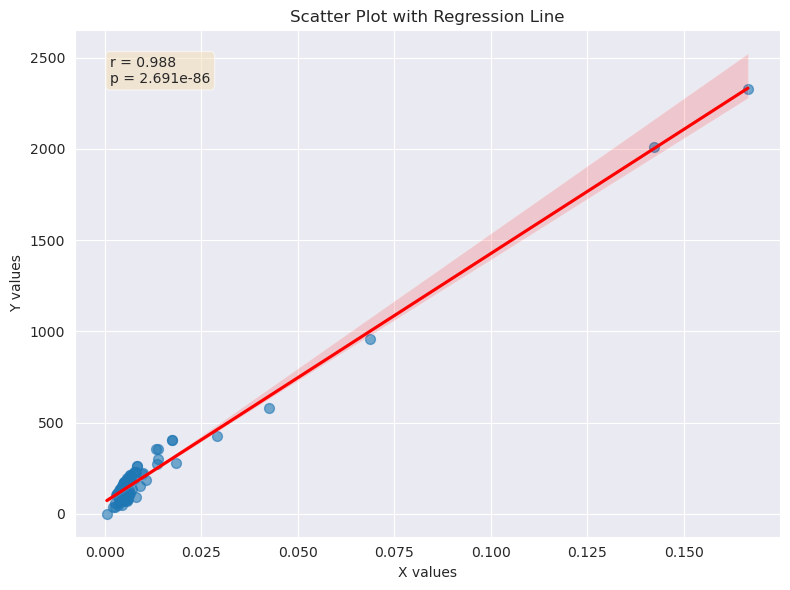

In [34]:
plot_xy(cm_bl, cm_cc)
# plot_xy(cm_bl, cm_cc, x_cutoff=log(1.025))

### MEDICC2

In [35]:
# for each cell
med_bl = get_cells_branch_lengths(med_tree_nwk, cell_names)
med_cc = get_cells_cn_changes(medicc_adata_cells.layers['medicc2-cn'], cell_names)  # MEDICC CN 0.83 pearson correlation
# med_cc = get_cells_cn_changes(adata.layers['cellmates-cn'], cell_names)  # CELLMATES CN 0.44
# med_cc = get_cells_cn_changes(adata.layers['state'], cell_names)  # HMMCopy 0.68



pearson correlation: 0.8346000530627293
p-value: 1.9868201838570064e-28


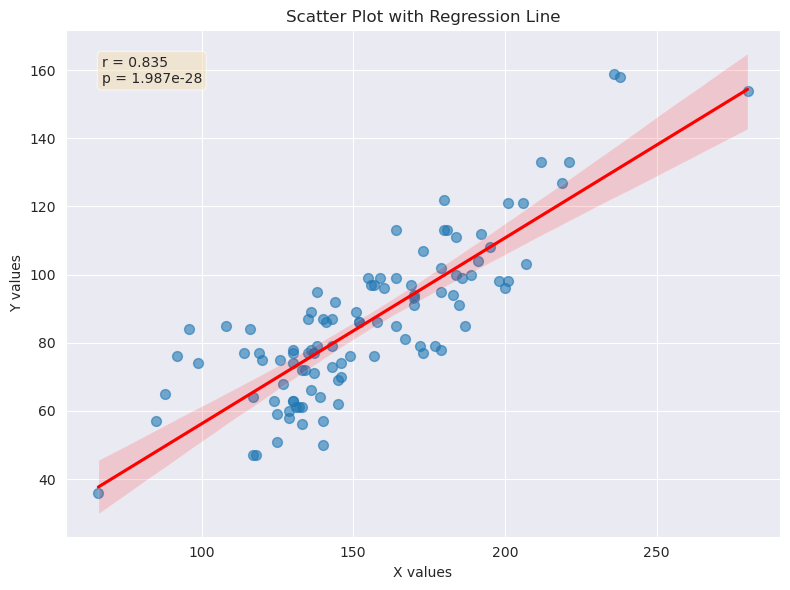

In [36]:
plot_xy(med_bl, med_cc)

## The birthday problem
With many cells it is more likely that two unrelated cells share the same breakpoint. For each breakpoint detected in cellmates, we count the number of cells that exhibit that breakpoint

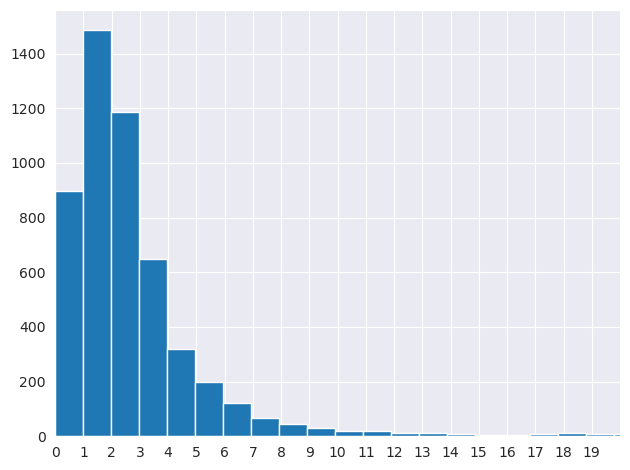

In [46]:
bkpt = np.diff(adata.layers['cellmates-cn'])
plt.hist(np.sum(bkpt != 0, axis=0), bins=100)
plt.xlim(0,20)
plt.xticks(np.arange(0, 20, 1))
plt.tight_layout()

In [49]:
np.sum(np.sum(bkpt != 0, axis=0) < 1)

np.int64(897)